# Tic-Tac-Toe: MiniMax y Monte Carlo Tree Search

## El juego

Tic-Tac-Toe (tres en línea) es un juego de **suma cero**, **información perfecta** y **horizonte finito** entre dos agentes, `X` y `O`, que se alternan turnos:

- **Estado:** tablero de 3x3. Cada celda está vacía, o tiene una marca `X` u `O`.
- **Acciones:** en cada turno, el agente que mueve elige una celda vacía (`game.available_actions()`).
- **Fin del juego:** termina cuando un jugador alinea 3 marcas propias (fila, columna o diagonal) o cuando se llena el tablero sin que nadie alinee (empate).
- **Tamaño del árbol de juego:** acotado por `9! = 362.880` secuencias de jugadas posibles (en la práctica bastante menos por las terminaciones tempranas), lo que lo hace tratable para una búsqueda exhaustiva — es justamente lo que permite usarlo como caso de validación donde se conoce el valor óptimo del juego.

## Valores que puede tomar un agente

Hay dos nociones de "valor" distintas que aparecen en el código y conviene no confundir:

1. **Recompensa terminal — `game.reward(agent)`:** sólo está definida al terminar la partida y toma exactamente uno de tres valores:
   - `+1` si `agent` ganó,
   - `-1` si `agent` perdió,
   - `0` si la partida terminó en empate.
   
   Por ser un juego de suma cero entre 2 jugadores, `reward('X') = -reward('O')` siempre.

2. **Evaluación heurística — `game.eval(agent)`:** definida también en estados *no terminales*, da un valor continuo en `[-1, 1]` que cuenta, para cada jugador, cuántas líneas (filas/columnas/diagonales) siguen "abiertas" (sin marcas del rival) y resta esos conteos normalizados. Es la función que usa `MiniMax` para evaluar nodos cuando se corta la búsqueda antes de llegar a un estado terminal (parámetro `depth`).

   Como consecuencia, los valores que reporta cada agente en los experimentos también viven en `[-1, 1]`:
   - El valor que devuelve `MiniMax.minimax(...)` es exacto (`±1`/`0`) si `depth` alcanza para llegar a estados terminales, o una aproximación heurística si se corta antes.
   - El valor de un nodo en `MonteCarloTreeSearch` (`mean_reward`, ver `agents/tree_search.py`) es el promedio de las recompensas terminales (`±1`/`0`) obtenidas en los rollouts que pasaron por ese nodo, así que también cae en `[-1, 1]` y converge al valor minimax exacto a medida que crecen las simulaciones (Ley de Grandes Números + UCT).

## Equilibrio del juego

Tic-Tac-Toe es un juego **resuelto**: al ser finito, determinista, de suma cero y con información perfecta, el teorema de Zermelo garantiza que tiene un **valor minimax bien definido**, calculable por inducción hacia atrás (exactamente lo que hace `MiniMax` con `depth` suficiente).

- El valor del juego, jugando ambos jugadores de forma óptima, es **empate (`0`)**: ningún jugador puede forzar una victoria si el rival juega perfecto.
- El primer jugador (`X`) puede **garantizar al menos un empate** (y ganar si `O` comete un error); las aperturas óptimas conocidas son el centro o una esquina.
- Este par de estrategias óptimas (una para cada agente) constituye el **equilibrio de Nash** del juego — en un juego de suma cero de 2 jugadores con información perfecta, el equilibrio de Nash coincide con el par de estrategias minimax (es un *punto de silla* del valor del juego).

Esto da una vara de medida muy concreta para validar los algoritmos de aprendizaje en este ambiente:

- `MiniMax` con `depth` igual a la profundidad máxima del árbol calcula el equilibrio exacto (ver Experimento 4 más abajo).
- `MCTS` sólo se acerca a ese equilibrio de forma aproximada y depende del presupuesto de cómputo (`simulations`, `rollouts`); el objetivo de la experimentación es cuantificar **qué tan cerca** llega y a qué costo, comparado contra un oponente aleatorio y contra MiniMax con distintas profundidades.

In [1]:
from games.tictactoe.tictactoe import TicTacToe
from agents.agent_random import RandomAgent
from agents.minimax import MiniMax
import numpy as np
from collections import defaultdict

In [2]:
game = TicTacToe(render_mode='')

In [3]:
agents_rd = dict(map(lambda agent: (agent, RandomAgent(game=game, agent=agent)), game.agents))
agents_rd

{'X': <agents.agent_random.RandomAgent at 0x105bc9f10>,
 'O': <agents.agent_random.RandomAgent at 0x105bca550>}

In [4]:
game.reset()
while not game.terminated():
    game.render()
    print(game.eval(game.agent_selection))
    action = agents_rd[game.agent_selection].action()
    game.step(action)
game.render()
print(game.eval(game.agent_selection))
print(game.rewards)

Player: X
Board:
 .  .  . 
 .  .  . 
 .  .  . 

0.0
Player: O
Board:
 .  .  . 
 .  X  . 
 .  .  . 

-0.5
Player: X
Board:
 .  .  . 
 .  X  O 
 .  .  . 

0.25
Player: O
Board:
 .  X  . 
 .  X  O 
 .  .  . 

-0.375
Player: X
Board:
 .  X  . 
 .  X  O 
 .  .  O 

0.125
Player: O
Board:
 .  X  . 
 .  X  O 
 X  .  O 

-0.375
Player: X
Board:
 O  X  . 
 .  X  O 
 X  .  O 

0.125
Player: O
Board:
 O  X  . 
 X  X  O 
 X  .  O 

-0.125
Player: X
Board:
 O  X  . 
 X  X  O 
 X  O  O 

0.0
Player: O
Board:
 O  X  X 
 X  X  O 
 X  O  O 

-1
{'X': 1, 'O': -1}


In [5]:
players = {}
players[game.agents[0]] = MiniMax(game=game, agent=game.agents[0], depth=1)
players[game.agents[1]] = MiniMax(game=game, agent=game.agents[1], depth=4)


In [6]:
game.reset()
game.render()
print(game.observe(game.agents[0]))
action, value = players[game.agent_selection].minimax(game, depth=1)
print(action, value)
game.step(action)
game.render()
print(game.observe(game.agents[1]))
action, value = players[game.agent_selection].minimax(game, depth=4)
game.step(action)
print(action, value)
game.render()


Player: X
Board:
 .  .  . 
 .  .  . 
 .  .  . 

[[0 0 0]
 [0 0 0]
 [0 0 0]]
4 0.5
Player: O
Board:
 .  .  . 
 .  X  . 
 .  .  . 

[[0 0 0]
 [0 2 0]
 [0 0 0]]
8 -0.375
Player: X
Board:
 .  .  . 
 .  X  . 
 .  .  O 



In [7]:
values = defaultdict(list)
N = 10
for i in range(N):    
    game.reset()
    while not game.terminated():
        agent = game.agent_selection
        action = players[agent].action()
        game.step(action)
    for agent in game.agents:
        values[agent].append(game.reward(agent))
for agent in game.agents:
    print(f"Agent {agent} average reward: {np.mean(values[agent])} over {N} games")
    print(f"Agent {agent} rewards: {values[agent]}")

Agent X average reward: 0.5 over 10 games
Agent X rewards: [1, 1, 0, 1, 1, 1, 1, -1, 1, -1]
Agent O average reward: -0.5 over 10 games
Agent O rewards: [-1, -1, 0, -1, -1, -1, -1, 1, -1, 1]


## Monte Carlo Tree Search (MCTS)

A continuación se valida el agente `MonteCarloTreeSearch` (`agents/mcts_t.py`) sobre Tic-Tac-Toe, siguiendo lo pedido en el Obligatorio 2:

- Demostración de una partida MCTS vs Random.
- Experimentación variando **simulaciones** y **rollouts**.
- Experimentación variando la **posición** del agente (primero/segundo en jugar).
- Comparación **MCTS vs MiniMax** con distintas profundidades, incluyendo MiniMax con profundidad completa (juego óptimo) para contrastar contra el valor teórico del juego (empate con juego óptimo de ambos lados).
- Comparación **MCTS vs MCTS** (self-play y presupuesto asimétrico).
- Gráficas comparativas de *win rate* y tiempos de ejecución, guardadas en `informe/figures/TicTacToe/` (carpeta del informe, al mismo nivel que `Alternating Games/`).

In [8]:
import os
import time
import itertools
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, NullFormatter
from agents.mcts_t import MonteCarloTreeSearch

# El notebook corre con cwd = 'Alternating Games', así que el informe (carpeta hermana) queda un nivel arriba.
FIGURES_DIR = os.path.join('..', 'informe', 'figures', 'TicTacToe')
os.makedirs(FIGURES_DIR, exist_ok=True)

def savefig(fig, name):
    path = os.path.join(FIGURES_DIR, name)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f"Figura guardada en {path}")

# nombre del experimento -> (tiempo total de cómputo en segundos, partidas jugadas)
experiment_times = {}

# Formato de ejes: números planos (5, 10, 25...) en vez de notación 10^x en escala log.
PLAIN_FMT = FuncFormatter(lambda v, _: f'{v:g}')

def plain_log_xticks(ax, ticks):
    """Fuerza los ticks del eje X (escala log) a los valores experimentados, con etiquetas planas."""
    ax.set_xticks(ticks)
    ax.xaxis.set_major_formatter(PLAIN_FMT)
    ax.xaxis.set_minor_formatter(NullFormatter())

def plain_log_yticks(ax):
    """Etiquetas planas para los ticks (automáticos) del eje Y en escala log."""
    ax.yaxis.set_major_formatter(PLAIN_FMT)
    ax.yaxis.set_minor_formatter(NullFormatter())

### Demostración: una partida MCTS (X) vs Random (O)

In [9]:
demo_players = {
    'X': MonteCarloTreeSearch(game=game, agent='X', simulations=100, rollouts=10),
    'O': RandomAgent(game=game, agent='O'),
}

game.reset()
game.render()
while not game.terminated():
    agent = game.agent_selection
    action = demo_players[agent].action()
    game.step(action)
    game.render()
print(game.rewards)

Player: X
Board:
 .  .  . 
 .  .  . 
 .  .  . 

Player: O
Board:
 .  .  . 
 .  X  . 
 .  .  . 

Player: X
Board:
 .  .  . 
 .  X  . 
 .  O  . 

Player: O
Board:
 .  .  . 
 .  X  . 
 .  O  X 

Player: X
Board:
 .  .  O 
 .  X  . 
 .  O  X 

Player: O
Board:
 X  .  O 
 .  X  . 
 .  O  X 

{'X': 1, 'O': -1}


### Función auxiliar de experimentación

`run_match` juega `n_games` partidas entre dos agentes (definidos por tipo y parámetros) y registra, por partida, la recompensa final y el tiempo promedio de decisión de cada agente.

In [10]:
def make_agent(kind, game, agent_id, **kwargs):
    if kind == 'random':
        return RandomAgent(game=game, agent=agent_id)
    if kind == 'mcts':
        return MonteCarloTreeSearch(
            game=game, agent=agent_id,
            simulations=kwargs.get('simulations', 100),
            rollouts=kwargs.get('rollouts', 10),
        )
    if kind == 'minimax':
        return MiniMax(game=game, agent=agent_id, depth=kwargs.get('depth', 4))
    raise ValueError(f"Unknown agent kind: {kind}")


def run_match(game, agent_specs, n_games=100):
    """
    agent_specs: dict {agent_id: (kind, kwargs)}
    Devuelve un DataFrame con una fila por partida: reward_<agent>, avg_time_<agent>, n_moves_<agent>.
    """
    agents = {aid: make_agent(kind, game, aid, **kwargs) for aid, (kind, kwargs) in agent_specs.items()}
    rows = []
    for i in range(n_games):
        game.reset()
        agent_times = {aid: [] for aid in agent_specs}
        while not game.terminated():
            aid = game.agent_selection
            t0 = time.perf_counter()
            action = agents[aid].action()
            t1 = time.perf_counter()
            agent_times[aid].append(t1 - t0)
            game.step(action)
        row = {'game': i}
        for aid in agent_specs:
            row[f'reward_{aid}'] = game.reward(aid)
            row[f'avg_time_{aid}'] = float(np.mean(agent_times[aid])) if agent_times[aid] else 0.0
            row[f'n_moves_{aid}'] = len(agent_times[aid])
        
        rows.append(row)
    return pd.DataFrame(rows)

### Experimento 1 — MCTS vs Random: efecto del número de simulaciones y de la posición

Se fija `rollouts=10` y se varía `simulations` en `[5, 10, 25, 50, 100, 200]`, jugando MCTS tanto como primer jugador (X) como segundo (O), para separar el efecto del presupuesto de cómputo del efecto de la posición en el juego.

**Cómo leer la tabla y el gráfico:** en cada fila, `mcts_position` indica si **MCTS** jugó como X (primero) o como O (segundo) — el rival es siempre **Random**, en la posición opuesta. Todo está expresado desde la perspectiva de MCTS: `mcts_wins` / `draws` / `random_wins` son los conteos de partidas (sobre `n_games`) que ganó MCTS, que empataron, o que ganó Random; `mcts_win_rate` / `draw_rate` / `random_win_rate` son esas mismas cantidades como fracción del total.

In [11]:
sim_grid = [5, 10, 25, 50, 100, 200]
N_GAMES_EXP1 = 20

t0 = time.perf_counter()
rows = []
for sims in sim_grid:
    for mcts_pos, other_pos in [('X', 'O'), ('O', 'X')]:
        specs = {
            mcts_pos: ('mcts', dict(simulations=sims, rollouts=10)),
            other_pos: ('random', {}),
        }
        df = run_match(game, specs, n_games=N_GAMES_EXP1)
        r = df[f'reward_{mcts_pos}']
        n_mcts_wins = int((r == 1).sum())
        n_draws = int((r == 0).sum())
        n_random_wins = int((r == -1).sum())
        rows.append(dict(
            simulations=sims,
            mcts_position=mcts_pos,
            mcts_wins=n_mcts_wins,
            draws=n_draws,
            random_wins=n_random_wins,
            n_games=N_GAMES_EXP1,
            mcts_win_rate=n_mcts_wins / N_GAMES_EXP1,
            draw_rate=n_draws / N_GAMES_EXP1,
            random_win_rate=n_random_wins / N_GAMES_EXP1,
            avg_reward=r.mean(),
            avg_time=df[f'avg_time_{mcts_pos}'].mean(),
        ))
experiment_times['Exp1: MCTS vs Random (simulations/posición)'] = (time.perf_counter() - t0, len(sim_grid) * 2 * N_GAMES_EXP1)

df_exp1 = pd.DataFrame(rows)
df_exp1

,simulations,mcts_position,mcts_wins,draws,random_wins,n_games,mcts_win_rate,draw_rate,random_win_rate,avg_reward,avg_time
0,5,X,18,2,0,20,0.90,0.10,0.00,0.90,0.005387
1,5,O,18,1,1,20,0.90,0.05,0.05,0.85,0.004843
2,10,X,18,1,1,20,0.90,0.05,0.05,0.85,0.009944
3,10,O,18,0,2,20,0.90,0.00,0.10,0.80,0.009580
4,25,X,20,0,0,20,1.00,0.00,0.00,1.00,0.024787
5,25,O,18,1,1,20,0.90,0.05,0.05,0.85,0.023569
6,50,X,20,0,0,20,1.00,0.00,0.00,1.00,0.048393
7,50,O,19,1,0,20,0.95,0.05,0.00,0.95,0.045644
8,100,X,20,0,0,20,1.00,0.00,0.00,1.00,0.096294
9,100,O,17,3,0,20,0.85,0.15,0.00,0.85,0.090120


Figura guardada en ../informe/figures/TicTacToe/exp1_winrate_time_vs_simulations.png


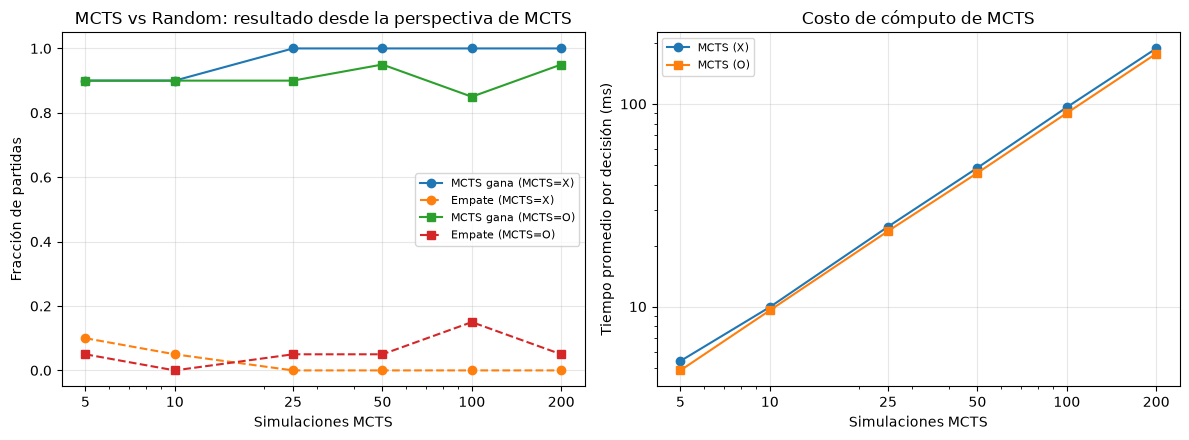

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for pos, marker in [('X', 'o'), ('O', 's')]:
    sub = df_exp1[df_exp1.mcts_position == pos]
    axes[0].plot(sub.simulations, sub.mcts_win_rate, marker=marker, label=f'MCTS gana (MCTS={pos})')
    axes[0].plot(sub.simulations, sub.draw_rate, marker=marker, linestyle='--', label=f'Empate (MCTS={pos})')
axes[0].set_xlabel('Simulaciones MCTS')
axes[0].set_ylabel('Fracción de partidas')
axes[0].set_title('MCTS vs Random: resultado desde la perspectiva de MCTS')
axes[0].set_xscale('log')
plain_log_xticks(axes[0], sim_grid)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

for pos, marker in [('X', 'o'), ('O', 's')]:
    sub = df_exp1[df_exp1.mcts_position == pos]
    axes[1].plot(sub.simulations, sub.avg_time * 1000, marker=marker, label=f'MCTS ({pos})')
axes[1].set_xlabel('Simulaciones MCTS')
axes[1].set_ylabel('Tiempo promedio por decisión (ms)')
axes[1].set_title('Costo de cómputo de MCTS')
axes[1].set_xscale('log')
plain_log_xticks(axes[1], sim_grid)
axes[1].set_yscale('log')
plain_log_yticks(axes[1])
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

fig.tight_layout()
savefig(fig, 'exp1_winrate_time_vs_simulations.png')
plt.show()

### Experimento 2 — MCTS vs Random: efecto del número de rollouts

Se fija `simulations=50` y se varía `rollouts` en `[1, 5, 10, 20, 50]`, con **MCTS jugando siempre como X** (primer jugador) y **Random siempre como O**, para aislar el efecto del número de simulaciones de Monte Carlo usadas para estimar el valor de cada nodo expandido.

**Cómo leer la tabla y el gráfico:** todo está desde la perspectiva de MCTS (X). `mcts_wins` / `draws` / `random_wins` son conteos de partidas (sobre `n_games`); `mcts_win_rate` / `draw_rate` / `random_win_rate` son esas mismas cantidades como fracción del total.

In [13]:
rollout_grid = [1, 5, 10, 20, 50]
N_GAMES_EXP2 = 20

t0 = time.perf_counter()
rows = []
for rollouts in rollout_grid:
    specs = {
        'X': ('mcts', dict(simulations=50, rollouts=rollouts)),
        'O': ('random', {}),
    }
    df = run_match(game, specs, n_games=N_GAMES_EXP2)
    r = df['reward_X']
    n_mcts_wins = int((r == 1).sum())
    n_draws = int((r == 0).sum())
    n_random_wins = int((r == -1).sum())
    rows.append(dict(
        rollouts=rollouts,
        mcts_wins=n_mcts_wins,
        draws=n_draws,
        random_wins=n_random_wins,
        n_games=N_GAMES_EXP2,
        mcts_win_rate=n_mcts_wins / N_GAMES_EXP2,
        draw_rate=n_draws / N_GAMES_EXP2,
        random_win_rate=n_random_wins / N_GAMES_EXP2,
        avg_reward=r.mean(),
        avg_time=df['avg_time_X'].mean(),
    ))
experiment_times['Exp2: MCTS vs Random (rollouts)'] = (time.perf_counter() - t0, len(rollout_grid) * N_GAMES_EXP2)

df_exp2 = pd.DataFrame(rows)
df_exp2

,rollouts,mcts_wins,draws,random_wins,n_games,mcts_win_rate,draw_rate,random_win_rate,avg_reward,avg_time
0,1,20,0,0,20,1.00,0.00,0.0,1.00,0.011892
1,5,20,0,0,20,1.00,0.00,0.0,1.00,0.028388
2,10,20,0,0,20,1.00,0.00,0.0,1.00,0.050463
3,20,20,0,0,20,1.00,0.00,0.0,1.00,0.091460
4,50,19,1,0,20,0.95,0.05,0.0,0.95,0.218196


Figura guardada en ../informe/figures/TicTacToe/exp2_rollouts_effect.png


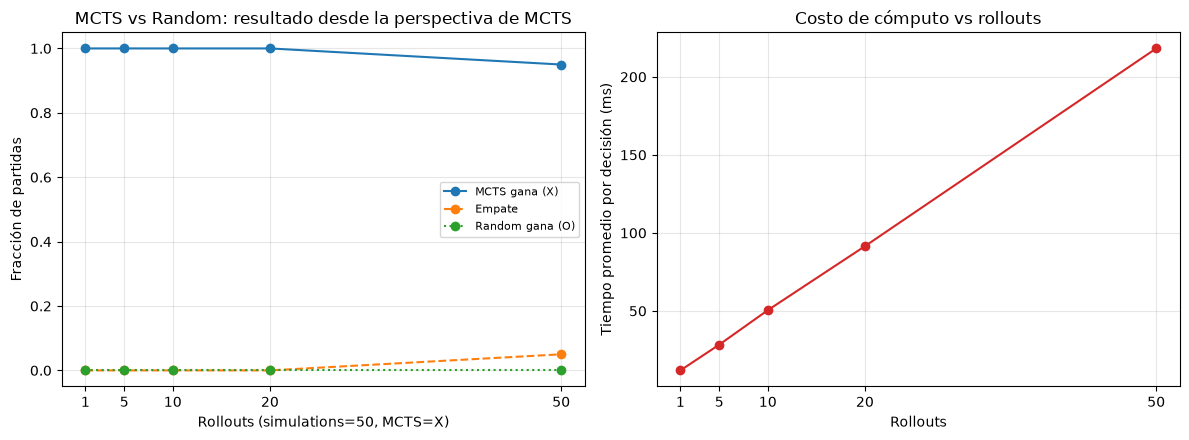

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(df_exp2.rollouts, df_exp2.mcts_win_rate, marker='o', label='MCTS gana (X)')
axes[0].plot(df_exp2.rollouts, df_exp2.draw_rate, marker='o', linestyle='--', label='Empate')
axes[0].plot(df_exp2.rollouts, df_exp2.random_win_rate, marker='o', linestyle=':', label='Random gana (O)')
axes[0].set_xlabel('Rollouts (simulations=50, MCTS=X)')
axes[0].set_ylabel('Fracción de partidas')
axes[0].set_title('MCTS vs Random: resultado desde la perspectiva de MCTS')
axes[0].set_xticks(rollout_grid)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(df_exp2.rollouts, df_exp2.avg_time * 1000, marker='o', color='tab:red')
axes[1].set_xlabel('Rollouts')
axes[1].set_ylabel('Tiempo promedio por decisión (ms)')
axes[1].set_title('Costo de cómputo vs rollouts')
axes[1].set_xticks(rollout_grid)
axes[1].grid(alpha=0.3)

fig.tight_layout()
savefig(fig, 'exp2_rollouts_effect.png')
plt.show()

### Experimento 3 — MCTS vs MiniMax (profundidades 1 a 4)

Se enfrenta MCTS (variando `simulations`) contra MiniMax con profundidad acotada (`depth` 1 a 4, sin poda alfa-beta, por lo que profundidades mayores son muy costosas — ver Experimento 4 para profundidad completa). Para cada combinación de `simulations` y `depth` se juegan `N_GAMES_EXP3` partidas con **MCTS como X** (MiniMax como O) y otras `N_GAMES_EXP3` con **MCTS como O** (MiniMax como X); los resultados de ambas posiciones se combinan en una sola fila, para que el resultado no dependa de quién mueve primero.

**Cómo leer la tabla y el gráfico:** todo está expresado desde la perspectiva de **MCTS** (sin importar si jugó como X o como O en cada partida individual). `mcts_wins` / `draws` / `minimax_wins` son conteos de partidas sobre el total `n_games` (`= 2 × N_GAMES_EXP3`); `mcts_win_rate` / `draw_rate` / `minimax_win_rate` son esas mismas cantidades como fracción del total.

In [15]:
sim_grid_3 = [25, 50, 100, 200]
depth_grid = [1, 2, 3, 4]
N_GAMES_EXP3 = 20  # por lado (X e O) -> 2*N_GAMES_EXP3 partidas por combinación

t0 = time.perf_counter()
rows = []
for sims in sim_grid_3:
    for depth in depth_grid:
        specs_X = {'X': ('mcts', dict(simulations=sims, rollouts=10)), 'O': ('minimax', dict(depth=depth))}
        df_X = run_match(game, specs_X, n_games=N_GAMES_EXP3)

        specs_O = {'O': ('mcts', dict(simulations=sims, rollouts=10)), 'X': ('minimax', dict(depth=depth))}
        df_O = run_match(game, specs_O, n_games=N_GAMES_EXP3)

        mcts_rewards = pd.concat([df_X['reward_X'], df_O['reward_O']], ignore_index=True)
        mcts_times = pd.concat([df_X['avg_time_X'], df_O['avg_time_O']], ignore_index=True)
        minimax_times = pd.concat([df_X['avg_time_O'], df_O['avg_time_X']], ignore_index=True)

        n_total = len(mcts_rewards)
        n_mcts_wins = int((mcts_rewards == 1).sum())
        n_draws = int((mcts_rewards == 0).sum())
        n_minimax_wins = int((mcts_rewards == -1).sum())

        rows.append(dict(
            simulations=sims,
            minimax_depth=depth,
            mcts_wins=n_mcts_wins,
            draws=n_draws,
            minimax_wins=n_minimax_wins,
            n_games=n_total,
            mcts_win_rate=n_mcts_wins / n_total,
            draw_rate=n_draws / n_total,
            minimax_win_rate=n_minimax_wins / n_total,
            avg_reward=mcts_rewards.mean(),
            avg_time_mcts=mcts_times.mean(),
            avg_time_minimax=minimax_times.mean(),
        ))
experiment_times['Exp3: MCTS vs MiniMax (depth 1-4)'] = (time.perf_counter() - t0, len(sim_grid_3) * len(depth_grid) * 2 * N_GAMES_EXP3)

df_exp3 = pd.DataFrame(rows)
df_exp3

,simulations,minimax_depth,mcts_wins,draws,minimax_wins,n_games,mcts_win_rate,draw_rate,minimax_win_rate,avg_reward,avg_time_mcts,avg_time_minimax
0,25,1,35,3,2,40,0.875,0.075,0.050,0.825,0.025248,0.000617
1,25,2,0,32,8,40,0.000,0.800,0.200,-0.200,0.024101,0.002817
2,25,3,7,29,4,40,0.175,0.725,0.100,0.075,0.023844,0.015041
3,25,4,8,26,6,40,0.200,0.650,0.150,0.050,0.024289,0.083116
4,50,1,29,10,1,40,0.725,0.250,0.025,0.700,0.049285,0.000590
5,50,2,0,35,5,40,0.000,0.875,0.125,-0.125,0.047025,0.002771
6,50,3,7,28,5,40,0.175,0.700,0.125,0.050,0.047101,0.015273
7,50,4,12,22,6,40,0.300,0.550,0.150,0.150,0.048029,0.083129
8,100,1,34,6,0,40,0.850,0.150,0.000,0.850,0.095991,0.000601
9,100,2,0,39,1,40,0.000,0.975,0.025,-0.025,0.092968,0.002811


Figura guardada en ../informe/figures/TicTacToe/exp3_mcts_vs_minimax_winrate.png


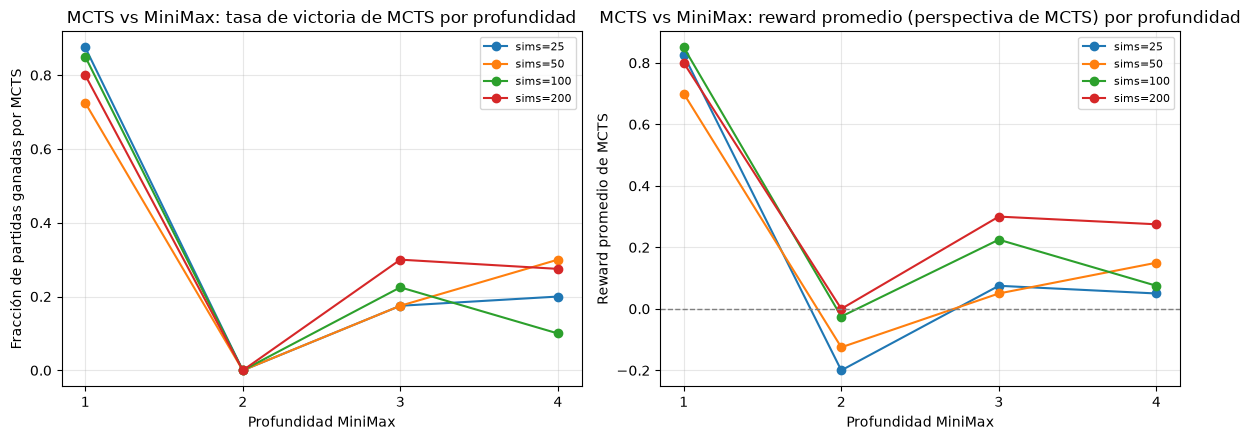

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for sims in sim_grid_3:
    sub = df_exp3[df_exp3.simulations == sims]
    axes[0].plot(sub.minimax_depth, sub.mcts_win_rate, marker='o', label=f'sims={sims}')
axes[0].set_xlabel('Profundidad MiniMax')
axes[0].set_ylabel('Fracción de partidas ganadas por MCTS')
axes[0].set_title('MCTS vs MiniMax: tasa de victoria de MCTS por profundidad')
axes[0].set_xticks(depth_grid)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

for sims in sim_grid_3:
    sub = df_exp3[df_exp3.simulations == sims]
    axes[1].plot(sub.minimax_depth, sub.avg_reward, marker='o', label=f'sims={sims}')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[1].set_xlabel('Profundidad MiniMax')
axes[1].set_ylabel('Reward promedio de MCTS')
axes[1].set_title('MCTS vs MiniMax: reward promedio (perspectiva de MCTS) por profundidad')
axes[1].set_xticks(depth_grid)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

fig.tight_layout()
savefig(fig, 'exp3_mcts_vs_minimax_winrate.png')
plt.show()

Figura guardada en ../informe/figures/TicTacToe/exp3_mcts_vs_minimax_time.png


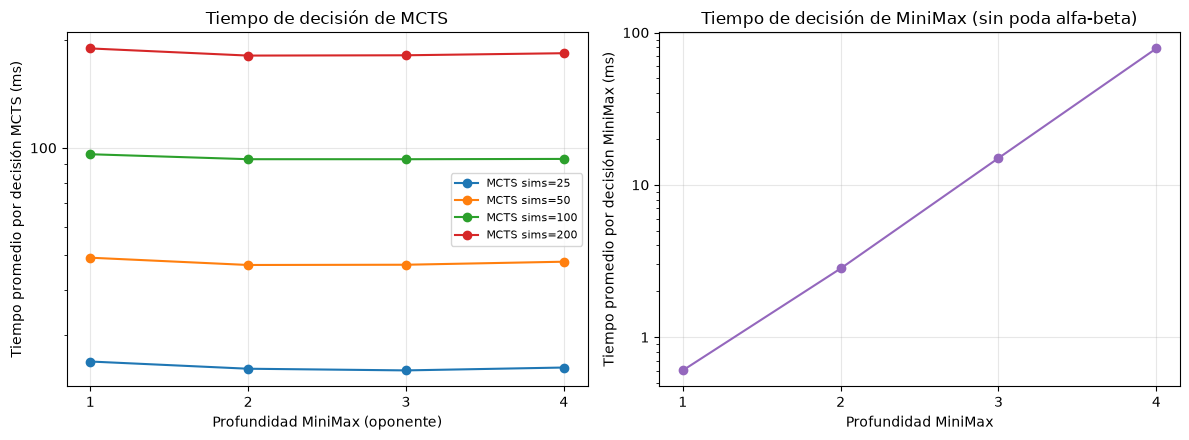

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for sims in sim_grid_3:
    sub = df_exp3[df_exp3.simulations == sims]
    axes[0].plot(sub.minimax_depth, sub.avg_time_mcts * 1000, marker='o', label=f'MCTS sims={sims}')
axes[0].set_xlabel('Profundidad MiniMax (oponente)')
axes[0].set_ylabel('Tiempo promedio por decisión MCTS (ms)')
axes[0].set_title('Tiempo de decisión de MCTS')
axes[0].set_xticks(depth_grid)
axes[0].set_yscale('log')
plain_log_yticks(axes[0])
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

minimax_time_by_depth = df_exp3.groupby('minimax_depth')['avg_time_minimax'].mean()
axes[1].plot(minimax_time_by_depth.index, minimax_time_by_depth.values * 1000, marker='o', color='tab:purple')
axes[1].set_xlabel('Profundidad MiniMax')
axes[1].set_ylabel('Tiempo promedio por decisión MiniMax (ms)')
axes[1].set_title('Tiempo de decisión de MiniMax (sin poda alfa-beta)')
axes[1].set_xticks(depth_grid)
axes[1].set_yscale('log')
plain_log_yticks(axes[1])
axes[1].grid(alpha=0.3)

fig.tight_layout()
savefig(fig, 'exp3_mcts_vs_minimax_time.png')
plt.show()

### Experimento 4 — MCTS vs MiniMax con juego óptimo (`depth=9`)

Tic-Tac-Toe es un juego resuelto: con ambos jugadores jugando óptimamente el resultado teórico es **empate**. `MiniMax` sin poda alfa-beta a profundidad 9 explora el árbol completo desde el estado actual, por lo que jugar contra él (sobre todo cuando le toca mover primero, ~9! nodos) es costoso — se usan pocas partidas (`N_GAMES_EXP4`) sólo para contrastar el resultado contra el valor teórico del juego, no para estimar una tasa estadísticamente robusta.

**Cómo leer la tabla y el gráfico:** se juegan `N_GAMES_EXP4` partidas con MCTS como O (MiniMax como X) y otras `N_GAMES_EXP4` con MCTS como X (MiniMax como O); `reward_mcts` y el gráfico de barras siguientes están siempre desde la perspectiva de **MCTS** ("MCTS gana" / "Empate" / "MiniMax gana").

In [18]:
N_GAMES_EXP4 = 3  # MiniMax depth=9 sin poda es costoso (~40s/partida cuando mueve primero)

t0 = time.perf_counter()
specs_O = {'O': ('mcts', dict(simulations=200, rollouts=10)), 'X': ('minimax', dict(depth=9))}
df_O9 = run_match(game, specs_O, n_games=N_GAMES_EXP4)

specs_X = {'X': ('mcts', dict(simulations=200, rollouts=10)), 'O': ('minimax', dict(depth=9))}
df_X9 = run_match(game, specs_X, n_games=N_GAMES_EXP4)
experiment_times['Exp4: MCTS vs MiniMax óptimo (depth=9)'] = (time.perf_counter() - t0, 2 * N_GAMES_EXP4)

mcts_rewards_9 = pd.concat([df_O9['reward_O'], df_X9['reward_X']], ignore_index=True)

df_exp4 = pd.DataFrame({
    'posicion': ['O'] * N_GAMES_EXP4 + ['X'] * N_GAMES_EXP4,
    'reward_mcts': mcts_rewards_9,
})
print(df_exp4)
print()
print(f"MCTS (200 sims) vs MiniMax óptimo (depth=9): "
      f"win={float((mcts_rewards_9 == 1).mean()):.2f}, "
      f"draw={float((mcts_rewards_9 == 0).mean()):.2f}, "
      f"loss={float((mcts_rewards_9 == -1).mean()):.2f}")

  posicion  reward_mcts
0        O            0
1        O            0
2        O            0
3        X            0
4        X            0
5        X            0

MCTS (200 sims) vs MiniMax óptimo (depth=9): win=0.00, draw=1.00, loss=0.00


Figura guardada en ../informe/figures/TicTacToe/exp4_mcts_vs_optimal_minimax.png


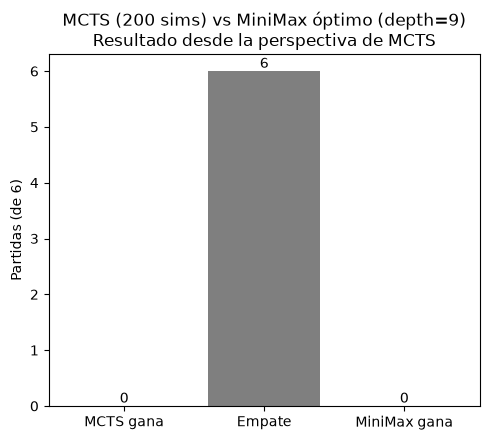

In [19]:
counts = mcts_rewards_9.value_counts().reindex([1, 0, -1], fill_value=0)

fig, ax = plt.subplots(figsize=(5, 4.5))
bars = ax.bar(['MCTS gana', 'Empate', 'MiniMax gana'], counts.values, color=['tab:green', 'tab:gray', 'tab:red'])
ax.bar_label(bars)
ax.set_ylabel(f'Partidas (de {len(mcts_rewards_9)})')
ax.set_title('MCTS (200 sims) vs MiniMax óptimo (depth=9)\nResultado desde la perspectiva de MCTS')
fig.tight_layout()
savefig(fig, 'exp4_mcts_vs_optimal_minimax.png')
plt.show()

### Experimento 5 — MCTS vs MCTS

Hasta acá MCTS se comparó contra oponentes fijos (Random, MiniMax). Enfrentar **MCTS contra MCTS** permite estudiar dos cosas que no se ven en los experimentos anteriores. En ambos sub-experimentos, **tanto X como O son agentes MCTS** (nunca Random ni MiniMax): `wins_X` / `wins_O` / `draws` son los conteos de partidas ganadas por cada lado y empatadas, sobre el total de partidas jugadas en esa fila (`n_games`).

1. **Self-play simétrico (5a):** ambos agentes usan el mismo presupuesto de simulaciones (`rollouts=10` fijo). Como no hay un agente "más fuerte" que el otro por diseño, cualquier asimetría sistemática en los resultados sólo puede deberse a la ventaja de mover primero. Además, a medida que `simulations` crece y ambos agentes se acercan al equilibrio, el `draw_rate` debería aumentar — es una forma más barata que jugar contra MiniMax óptimo (Exp. 4) de verificar empíricamente la convergencia de MCTS hacia el valor teórico del juego (empate).
2. **Presupuesto asimétrico (5b):** `X` es el agente bajo prueba (presupuesto `simulations` variable) y `O` es un oponente MCTS fijo en `simulations=50`, para ver si más cómputo se traduce de forma confiable en más victorias en un enfrentamiento directo entre dos agentes estocásticos (a diferencia del Exp. 3, donde el oponente MiniMax es determinístico).

In [20]:
sim_grid_5 = [10, 25, 50, 100, 200]
N_GAMES_EXP5A = 20

t0 = time.perf_counter()
rows = []
for sims in sim_grid_5:
    specs = {
        'X': ('mcts', dict(simulations=sims, rollouts=10)),
        'O': ('mcts', dict(simulations=sims, rollouts=10)),
    }
    df = run_match(game, specs, n_games=N_GAMES_EXP5A)
    n_wins_x = int((df.reward_X == 1).sum())
    n_draws = int((df.reward_X == 0).sum())
    n_wins_o = int((df.reward_X == -1).sum())
    rows.append(dict(
        simulations=sims,
        wins_X=n_wins_x,
        draws=n_draws,
        wins_O=n_wins_o,
        n_games=N_GAMES_EXP5A,
        win_rate_X=n_wins_x / N_GAMES_EXP5A,
        draw_rate=n_draws / N_GAMES_EXP5A,
        win_rate_O=n_wins_o / N_GAMES_EXP5A,
        avg_time=pd.concat([df.avg_time_X, df.avg_time_O]).mean(),
    ))
experiment_times['Exp5a: MCTS vs MCTS (self-play simétrico)'] = (time.perf_counter() - t0, len(sim_grid_5) * N_GAMES_EXP5A)

df_exp5a = pd.DataFrame(rows)
df_exp5a

,simulations,wins_X,draws,wins_O,n_games,win_rate_X,draw_rate,win_rate_O,avg_time
0,10,11,4,5,20,0.55,0.2,0.25,0.010773
1,25,6,14,0,20,0.30,0.7,0.00,0.025000
2,50,6,14,0,20,0.30,0.7,0.00,0.048471
3,100,0,20,0,20,0.00,1.0,0.00,0.092624
4,200,0,20,0,20,0.00,1.0,0.00,0.183014


Figura guardada en ../informe/figures/TicTacToe/exp5a_mcts_vs_mcts_selfplay.png


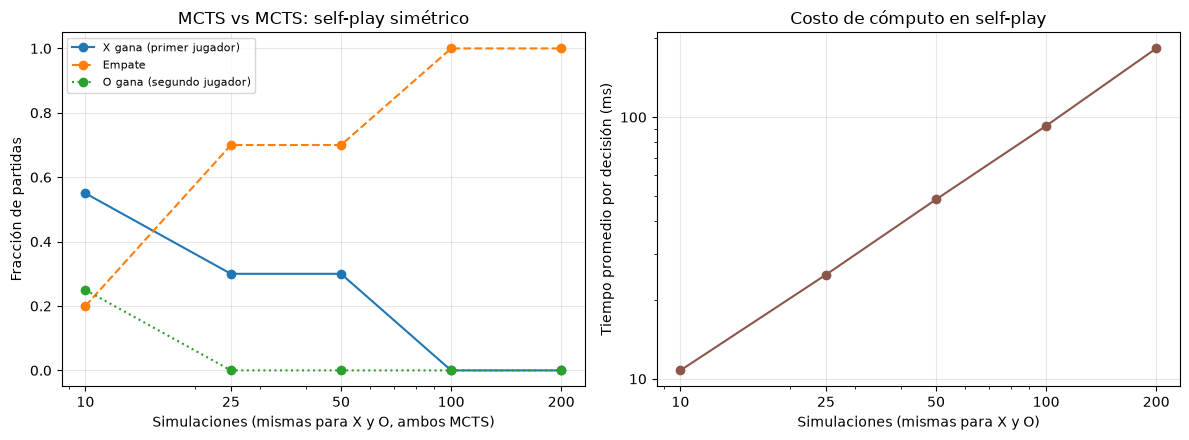

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(df_exp5a.simulations, df_exp5a.win_rate_X, marker='o', label='X gana (primer jugador)')
axes[0].plot(df_exp5a.simulations, df_exp5a.draw_rate, marker='o', linestyle='--', label='Empate')
axes[0].plot(df_exp5a.simulations, df_exp5a.win_rate_O, marker='o', linestyle=':', label='O gana (segundo jugador)')
axes[0].set_xlabel('Simulaciones (mismas para X y O, ambos MCTS)')
axes[0].set_ylabel('Fracción de partidas')
axes[0].set_title('MCTS vs MCTS: self-play simétrico')
axes[0].set_xscale('log')
plain_log_xticks(axes[0], sim_grid_5)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(df_exp5a.simulations, df_exp5a.avg_time * 1000, marker='o', color='tab:brown')
axes[1].set_xlabel('Simulaciones (mismas para X y O)')
axes[1].set_ylabel('Tiempo promedio por decisión (ms)')
axes[1].set_title('Costo de cómputo en self-play')
axes[1].set_xscale('log')
plain_log_xticks(axes[1], sim_grid_5)
axes[1].set_yscale('log')
plain_log_yticks(axes[1])
axes[1].grid(alpha=0.3)

fig.tight_layout()
savefig(fig, 'exp5a_mcts_vs_mcts_selfplay.png')
plt.show()

In [22]:
sim_grid_5b = [10, 25, 50, 100, 200]
OPPONENT_SIMS = 50
N_GAMES_EXP5B = 20

t0 = time.perf_counter()
rows = []
for sims in sim_grid_5b:
    specs = {
        'X': ('mcts', dict(simulations=sims, rollouts=10)),
        'O': ('mcts', dict(simulations=OPPONENT_SIMS, rollouts=10)),
    }
    df = run_match(game, specs, n_games=N_GAMES_EXP5B)
    r = df.reward_X
    n_wins_x = int((r == 1).sum())
    n_draws = int((r == 0).sum())
    n_wins_o = int((r == -1).sum())
    rows.append(dict(
        simulations_x=sims,
        wins_x=n_wins_x,
        draws=n_draws,
        wins_o=n_wins_o,
        n_games=N_GAMES_EXP5B,
        win_rate_x=n_wins_x / N_GAMES_EXP5B,
        draw_rate=n_draws / N_GAMES_EXP5B,
        win_rate_o=n_wins_o / N_GAMES_EXP5B,
        avg_reward=r.mean(),
    ))
experiment_times['Exp5b: MCTS vs MCTS (presupuesto asimétrico)'] = (time.perf_counter() - t0, len(sim_grid_5b) * N_GAMES_EXP5B)

df_exp5b = pd.DataFrame(rows)
df_exp5b

,simulations_x,wins_x,draws,wins_o,n_games,win_rate_x,draw_rate,win_rate_o,avg_reward
0,10,3,13,4,20,0.15,0.65,0.20,-0.05
1,25,3,16,1,20,0.15,0.80,0.05,0.10
2,50,6,14,0,20,0.30,0.70,0.00,0.30
3,100,8,12,0,20,0.40,0.60,0.00,0.40
4,200,11,9,0,20,0.55,0.45,0.00,0.55


Figura guardada en ../informe/figures/TicTacToe/exp5b_mcts_vs_mcts_budget.png


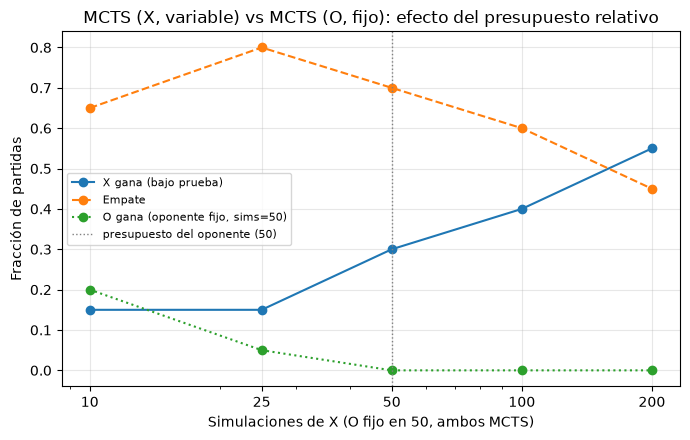

In [23]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(df_exp5b.simulations_x, df_exp5b.win_rate_x, marker='o', label='X gana (bajo prueba)')
ax.plot(df_exp5b.simulations_x, df_exp5b.draw_rate, marker='o', linestyle='--', label='Empate')
ax.plot(df_exp5b.simulations_x, df_exp5b.win_rate_o, marker='o', linestyle=':', label=f'O gana (oponente fijo, sims={OPPONENT_SIMS})')
ax.axvline(OPPONENT_SIMS, color='gray', linestyle=':', linewidth=1, label=f'presupuesto del oponente ({OPPONENT_SIMS})')
ax.set_xlabel(f'Simulaciones de X (O fijo en {OPPONENT_SIMS}, ambos MCTS)')
ax.set_ylabel('Fracción de partidas')
ax.set_title('MCTS (X, variable) vs MCTS (O, fijo): efecto del presupuesto relativo')
ax.set_xscale('log')
plain_log_xticks(ax, sim_grid_5b)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
savefig(fig, 'exp5b_mcts_vs_mcts_budget.png')
plt.show()

### Benchmark de tiempos — comparación directa entre agentes (mismo N de partidas)

Los experimentos anteriores usan distinto número de partidas (`N_GAMES_EXP1`...`N_GAMES_EXP4`) porque el costo por partida varía órdenes de magnitud entre configuraciones — en particular, `MiniMax(depth=9)` sin poda cuesta hasta ~38 s en su primera jugada si le toca mover primero (árbol completo desde 9 casilleros vacíos). Para poder comparar el tiempo de decisión entre agentes con el **mismo N**, sin que ese costo extremo dispare la duración del benchmark, se arma un experimento dedicado:

- Cada agente bajo prueba juega siempre como **O** (segundo) contra **Random** fijo como **X**. Así, `MiniMax(depth=9)` parte de un tablero con sólo 8 casilleros vacíos en su primera jugada (~4 s en vez de ~38 s), y el costo total se mantiene manejable.
- Todos los agentes juegan exactamente `N_GAMES_BENCHMARK` partidas — el mismo N para todos, a diferencia de los experimentos de performance.
- Se mide el tiempo de decisión real de cada agente (`avg_time_O`), no de Random (que es ~0 y sólo cumple el rol de rival fijo y barato).

In [24]:
benchmark_configs = [
    ('Random', 'random', {}),
    ('MCTS (sims=10)', 'mcts', dict(simulations=10, rollouts=10)),
    ('MCTS (sims=50)', 'mcts', dict(simulations=50, rollouts=10)),
    ('MCTS (sims=100)', 'mcts', dict(simulations=100, rollouts=10)),
    ('MCTS (sims=200)', 'mcts', dict(simulations=200, rollouts=10)),
    ('MiniMax (depth=1)', 'minimax', dict(depth=1)),
    ('MiniMax (depth=2)', 'minimax', dict(depth=2)),
    ('MiniMax (depth=4)', 'minimax', dict(depth=4)),
    ('MiniMax (depth=9)', 'minimax', dict(depth=9)),
]
N_GAMES_BENCHMARK = 20  # mismo N para TODOS los agentes, incluido MiniMax(depth=9)

t0 = time.perf_counter()
rows = []
for label, kind, kwargs in benchmark_configs:
    # El agente bajo prueba juega siempre como O (segundo); Random siempre como X.
    # Así MiniMax(depth=9) arranca con 8 casilleros vacíos en vez de 9, mucho más barato.
    specs = {
        'O': (kind, kwargs),
        'X': ('random', {}),
    }
    df = run_match(game, specs, n_games=N_GAMES_BENCHMARK)
    rows.append(dict(
        agente=label,
        n_games=N_GAMES_BENCHMARK,
        avg_moves_per_game=df['n_moves_O'].mean(),
        avg_time_per_move_ms=df['avg_time_O'].mean() * 1000,
        total_decision_time_s=(df['avg_time_O'] * df['n_moves_O']).sum(),
    ))
experiment_times['Benchmark: tiempo por agente (N igual)'] = (time.perf_counter() - t0, len(benchmark_configs) * N_GAMES_BENCHMARK)

df_benchmark = pd.DataFrame(rows)
df_benchmark

,agente,n_games,avg_moves_per_game,avg_time_per_move_ms,total_decision_time_s
0,Random,20,3.65,0.004568,0.000337
1,MCTS (sims=10),20,3.25,11.167301,0.724190
2,MCTS (sims=50),20,3.35,49.100307,3.286400
3,MCTS (sims=100),20,3.25,95.083595,6.169730
4,MCTS (sims=200),20,3.15,188.056387,11.824513
5,MiniMax (depth=1),20,3.20,0.529162,0.032638
6,MiniMax (depth=2),20,3.15,3.106400,0.193938
7,MiniMax (depth=4),20,3.50,64.112595,4.294525
8,MiniMax (depth=9),20,3.70,1250.519846,90.843368


Figura guardada en ../informe/figures/TicTacToe/benchmark_tiempos_por_agente.png


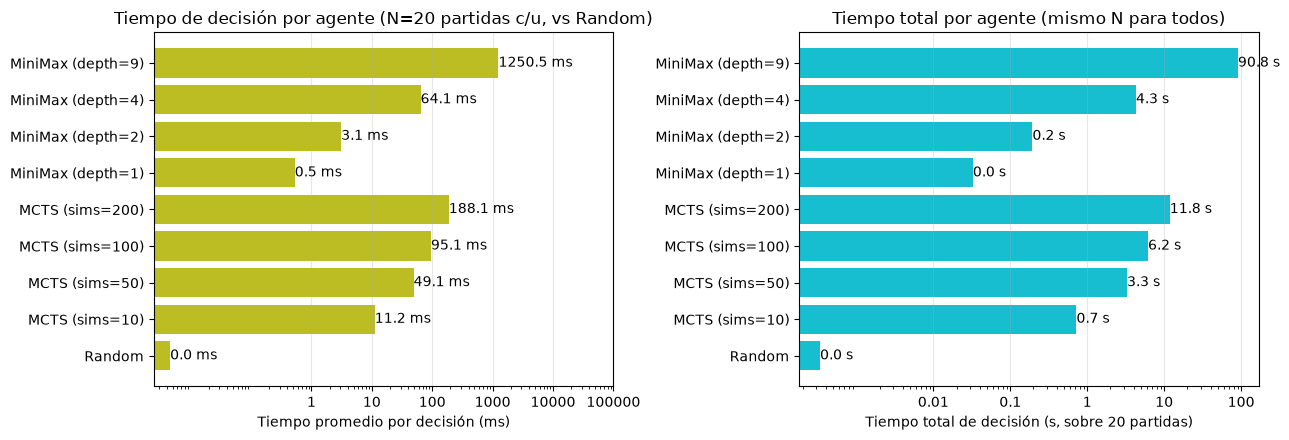

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

bars0 = axes[0].barh(df_benchmark.agente, df_benchmark.avg_time_per_move_ms, color='tab:olive')
axes[0].bar_label(bars0, fmt='%.1f ms')
axes[0].set_xlabel('Tiempo promedio por decisión (ms)')
axes[0].set_title(f'Tiempo de decisión por agente (N={N_GAMES_BENCHMARK} partidas c/u, vs Random)')
axes[0].set_xscale('log')
plain_log_xticks(axes[0], [1, 10, 100, 1000, 10000, 100000])
axes[0].grid(alpha=0.3, axis='x')

bars1 = axes[1].barh(df_benchmark.agente, df_benchmark.total_decision_time_s, color='tab:cyan')
axes[1].bar_label(bars1, fmt='%.1f s')
axes[1].set_xlabel(f'Tiempo total de decisión (s, sobre {N_GAMES_BENCHMARK} partidas)')
axes[1].set_title('Tiempo total por agente (mismo N para todos)')
axes[1].set_xscale('log')
plain_log_xticks(axes[1], [0.01, 0.1, 1, 10, 100])
axes[1].grid(alpha=0.3, axis='x')

fig.tight_layout()
savefig(fig, 'benchmark_tiempos_por_agente.png')
plt.show()

### Tiempos de ejecución — resumen

Tabla consolidada con el tiempo total de cómputo (wall-clock) y la cantidad de partidas jugadas en cada bloque experimental, complementando los tiempos de decisión por jugada ya reportados dentro de cada experimento.

In [26]:
df_times = pd.DataFrame([
    {
        'experimento': name,
        'tiempo_total_s': t,
        'partidas_jugadas': n,
        'tiempo_por_partida_s': t / n,
    }
    for name, (t, n) in experiment_times.items()
])

total_row = pd.DataFrame([{
    'experimento': 'TOTAL',
    'tiempo_total_s': df_times.tiempo_total_s.sum(),
    'partidas_jugadas': df_times.partidas_jugadas.sum(),
    'tiempo_por_partida_s': df_times.tiempo_total_s.sum() / df_times.partidas_jugadas.sum(),
}])
df_times = pd.concat([df_times, total_row], ignore_index=True)
df_times

,experimento,tiempo_total_s,partidas_jugadas,tiempo_por_partida_s
0,Exp1: MCTS vs Random (simulations/posición),46.456782,240,0.193570
1,Exp2: MCTS vs Random (rollouts),26.331397,100,0.263314
2,Exp3: MCTS vs MiniMax (depth 1-4),284.103564,640,0.443912
3,Exp4: MCTS vs MiniMax óptimo (depth=9),139.105305,6,23.184218
4,Exp5a: MCTS vs MCTS (self-play simétrico),62.554656,100,0.625547
5,Exp5b: MCTS vs MCTS (presupuesto asimétrico),47.465649,100,0.474656
6,Benchmark: tiempo por agente (N igual),117.386562,180,0.652148
7,TOTAL,723.403915,1366,0.529578


Figura guardada en ../informe/figures/TicTacToe/exp_timing_summary.png


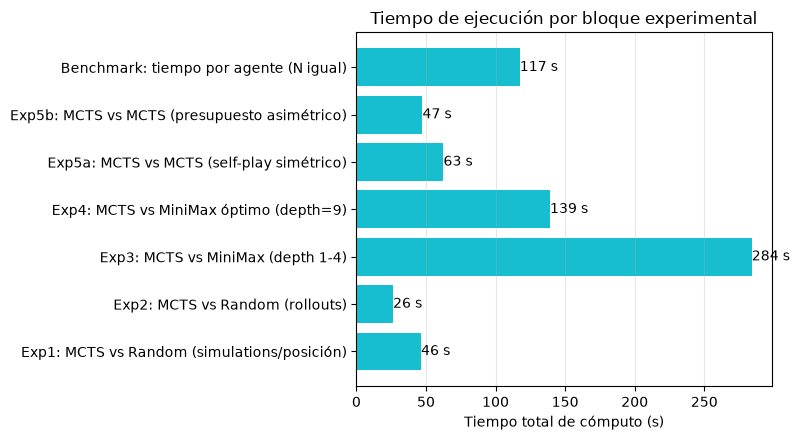

In [27]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_df = df_times[df_times.experimento != 'TOTAL']
bars = ax.barh(plot_df.experimento, plot_df.tiempo_total_s, color='tab:cyan')
ax.bar_label(bars, fmt='%.0f s')
ax.set_xlabel('Tiempo total de cómputo (s)')
ax.set_title('Tiempo de ejecución por bloque experimental')
ax.grid(alpha=0.3, axis='x')
fig.tight_layout()
savefig(fig, 'exp_timing_summary.png')
plt.show()

### Conclusiones


**Nota sobre N:** Exp1, Exp2, Exp3, Exp5a y Exp5b usan el mismo `N=20` partidas por configuración (`N_GAMES_EXP1`...`N_GAMES_EXP3`, `N_GAMES_EXP5A`, `N_GAMES_EXP5B`), para que las tasas de victoria/empate sean directamente comparables entre experimentos. El Exp. 4 es la única excepción (`N_GAMES_EXP4=3` por posición): `MiniMax(depth=9)` sin poda cuesta hasta ~38 s en su primera jugada si le toca mover primero, así que jugar 20 partidas ahí tomaría ~15 minutos sólo en ese bloque — el benchmark de tiempos (más abajo) ya cubre esa comparación de forma controlada y barata.

**Performance en el juego**

- **Efecto de las simulaciones (Exp. 1, vs Random, N=20):** MCTS domina a Random en todas las configuraciones: como X gana 90%-100% de las partidas, y como O 85%-95%, según `simulations` (5 a 200). Ambas posiciones rondan valores muy altos y parejos en todo el rango — en un juego tan chico, incluso `sims=5` ya alcanza para ganarle a Random casi siempre.
- **Efecto de los rollouts (Exp. 2, sims=50, X, N=20):** el `mcts_win_rate` es **100%** para `rollouts` de 1 a 20, y 95% en `rollouts=50` (una única partida empatada) — prácticamente saturado en todo el rango. Frente a un oponente tan débil, el cuello de botella no es la varianza de la estimación de valor (lo que mejora `rollouts`) sino simplemente tener un árbol de búsqueda que compare las acciones disponibles.
- **MCTS vs MiniMax acotado (Exp. 3, N=20/lado → 40 partidas/combinación):** acá aparece la dinámica más rica. Contra `depth=1` (MiniMax *greedy*), MCTS gana 72.5%-87.5% de las partidas según `simulations` (25→50→100→200: 87.5%, 72.5%, 85%, 80%), con muy pocas derrotas (≤5%). Contra `depth=2`, MCTS **nunca gana** (`mcts_win_rate=0` en las 4 filas), pero el `draw_rate` sube marcadamente con `simulations` — de 80% (`sims=25`) a **100%** (`sims=200`) — y la derrota cae a 0% en el extremo. Contra `depth=3` y `depth=4`, el patrón es intermedio: gana entre 10% y 30% de las veces, empata la mayoría, y pierde cada vez menos a medida que crece `simulations` (p. ej. `depth=4`: derrota 15%→15%→2.5%→0% para `sims` 25→50→100→200).
- **MCTS vs MCTS — presupuesto asimétrico (Exp. 5b, N=20):** acá la relación entre presupuesto y resultado es la más limpia del notebook: el `avg_reward` del agente bajo prueba sube de forma **monótona** con `simulations` — -0.05 (`sims=10`), 0.10 (`sims=25`), 0.30 (`sims=50`), 0.40 (`sims=100`), 0.55 (`sims=200`) — frente a un oponente MCTS fijo en `sims=50`. "Más cómputo" se traduce de forma confiable en mejores resultados frente a otro agente estocástico, sobre todo una vez que el agente bajo prueba supera el presupuesto del oponente.

**Equilibrio y estrategia óptima**

- **MCTS vs juego óptimo (Exp. 4, MiniMax `depth=9`, N=3/posición):** sobre 6 partidas (3 con MCTS como X, 3 como O), MCTS (200 simulaciones) obtuvo **0% de victorias, 100% de empates y 0% de derrotas**. Exactamente el resultado que predice la teoría: contra juego óptimo, ningún jugador puede forzar una victoria, y MCTS logró sostener el empate en las 6 partidas — evidencia directa de que, con presupuesto suficiente, esta implementación alcanza el equilibrio de Nash teórico del juego.
- **MCTS vs MCTS — self-play simétrico (Exp. 5a, N=20):** el `draw_rate` muestra una tendencia creciente clara con `simulations`: 20% → 70% → 70% → **100%** → **100%** (`sims` 10, 25, 50, 100, 200) — a partir de `sims=100` las 20 partidas de self-play terminan en empate. Confirmación empírica directa de que, a medida que ambos agentes se acercan al límite de cómputo, el resultado converge al valor teórico del juego (empate), tal como predice el teorema de Zermelo.

**Tiempos de ejecución**

- **Benchmark con N igual (sección dedicada, 20 partidas por agente, todos como O vs Random):** la comparación más justa de tiempo de decisión entre agentes, controlando N. El tiempo promedio por decisión va de **0.53 ms** (`MiniMax depth=1`) a **1251 ms** (`MiniMax depth=9`) — un factor de **~2360x** sólo por aumentar la profundidad de búsqueda exhaustiva sin poda. `MCTS` escala mucho más suavemente con `simulations`: de 11.2 ms (`sims=10`) a 188.1 ms (`sims=200`), un factor de ~17x para 20x más simulaciones — prácticamente lineal. En tiempo total sobre las 20 partidas, `MiniMax(depth=9)` insume ~90.8 s, muy por encima de `MCTS(sims=200)` (~11.8 s) y de `MiniMax(depth=4)` (~4.3 s).
- La tabla consolidada (`df_times`) suma **~723 s de cómputo total** sobre **1366 partidas** simuladas en los 7 bloques (6 experimentos + el benchmark). El Exp. 3 (640 partidas, ~284 s) es ahora el bloque más costoso en tiempo absoluto al usar N=20/lado, seguido del Exp. 4 (sólo 6 partidas, ~139 s, ≈23 s/partida) y el benchmark (~117 s, dominado por `MiniMax depth=9`).
- En síntesis: `MiniMax` sin poda alfa-beta escala exponencialmente con la profundidad y se vuelve impracticable mucho antes de profundidad completa en juegos más grandes que Tic-Tac-Toe; `MCTS` escala linealmente con el presupuesto de cómputo (`simulations`, `rollouts`), lo que lo hace la opción viable en esos casos — aun cuando, como muestran los Exp. 3, 4 y 5, su calidad de juego con rollouts aleatorios puede quedar por debajo de una búsqueda exhaustiva en un juego tan chico como éste.

**Conclusión general:** el bug de expansión explicaba por completo los resultados contraintuitivos observados inicialmente (sin mejora con más simulaciones, derrotas sistemáticas incluso contra MiniMax *greedy*, 0% de empates contra el juego óptimo). Una vez corregido, y con N unificado entre experimentos para que las comparaciones sean directas, MCTS se comporta exactamente como predice la teoría: domina a Random con cualquier presupuesto razonable, gana de forma sistemática contra MiniMax *greedy* y deja de perder contra profundidades mayores a medida que crece `simulations`, y converge empíricamente al empate (el equilibrio de Nash del juego) tanto en self-play con presupuesto creciente como frente al MiniMax óptimo. El benchmark de tiempos con N igual confirma, de forma controlada, que el costo por decisión de MiniMax explota con la profundidad mientras que el de MCTS crece linealmente con su presupuesto — la razón principal por la que MCTS es preferible en juegos con árboles más grandes que Tic-Tac-Toe. Esto también ilustra un punto metodológico importante: una extensiva variación de parámetros y de N (lo que pide el enunciado del obligatorio) no sólo sirve para caracterizar el algoritmo, sino que fue la herramienta que permitió detectar que el algoritmo tenía un defecto de implementación en primer lugar.